In [1]:
import sys
sys.path.append('../../')
from DEDi import ode_find as ode
from DEDi.ODE.PolyLib import *
import numpy as np
import matplotlib.pyplot as plt
from ODEForward.ODEFuncs import *

### Lorenz Oscillator

$(\sigma,\rho,\beta) = (10,28,8/3)$

\begin{align}
    \frac{dx}{dt} &= \sigma(y-x) \\
    \frac{dy}{dt} &= x(\rho - z) - y \\ 
    \frac{dz}{dt} &= xy - \beta z\\ 

\end{align}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(251, 3)


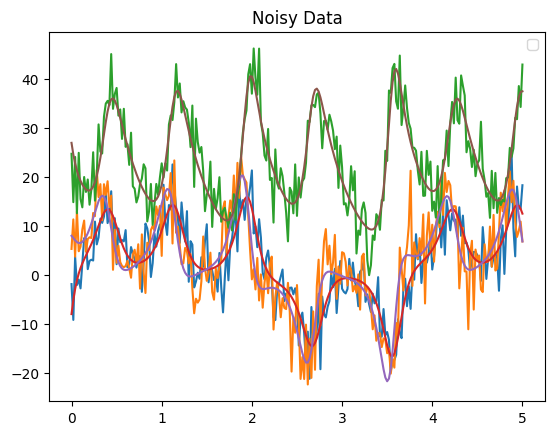

In [2]:
TSpan = (0,5)
dt = .02
x0 = [-8.0, 8.0, 27.0]


x_data_true = lorenzData(TSpan,dt,x0)

percent_noise = 0.5
noise = np.std(x_data_true,axis = 0)
np.random.seed(1)
x_data = x_data_true + np.random.normal(0,percent_noise*noise,size = x_data_true.shape)



T_grid = np.arange(TSpan[0], TSpan[1]+dt, dt)
plt.plot(T_grid,x_data)
plt.plot(T_grid,x_data_true)
plt.title('Noisy Data')
plt.legend()
Name = str(percent_noise) + "Noise"
# plt.savefig('Images/Lorenz/Orignal' + Name + '.pdf')
print(np.shape(x_data))
plt.show()

In [3]:
## If you want to mask the states
FractionOfDataMissing = 0.0
NumOfDataMissing = int(np.size(x_data)*FractionOfDataMissing)
state_mask = np.ones(np.size(x_data)).astype(bool)
state_mask[:NumOfDataMissing] = False
np.random.shuffle(state_mask)
state_mask = np.reshape(state_mask,np.shape(x_data))
x_data = x_data*state_mask #Just to show it is truly masking this data

In [4]:
Library = PolyFunc(num_vars=3,degree=2,constant=False)
print(Library)
discoverLorenz = ode(x_data,Library,[TSpan[0],TSpan[1]],
                     state_mask = state_mask,sparse_projections=None)

['x_1', 'x_2', 'x_3', 'x_1 x_2', 'x_1 x_3', 'x_1^2', 'x_2 x_3', 'x_2^2', 'x_3^2']
Setting up Sparse Hessian
Colors Needed = 38


In [5]:
guess = discoverLorenz.FindBestModel(objective_params = [1e-2,1e-4],
                                     tolerance = 1e-10,verbose=True,
                                     max_iterations = 500,method = "LM",
                                     info_criteria='BIC',
                                     drop_method = {"initial":'single',"k":3},
                                     LA_solver = 'cholesky')

1 | f = 81384949.813945, ||df|| = 8.699e+07, Alpha = 2.000e+01, SolverTime = 0.026s, HessianTime = 0.002s
1 | f = 81384949.813979, ||df|| = 8.699e+07, Alpha = 2.000e+01, SolverTime = 0.025s, HessianTime = 0.002s
2 | f = 68231753.217071, ||df|| = 7.152e+07, Alpha = 4.000e+00, SolverTime = 0.001s, HessianTime = 0.003s
2 | f = 68231753.217186, ||df|| = 7.152e+07, Alpha = 4.000e+00, SolverTime = 0.001s, HessianTime = 0.002s
3 | f = 35796092.726334, ||df|| = 3.787e+07, Alpha = 8.000e-01, SolverTime = 0.002s, HessianTime = 0.002s
3 | f = 35796092.726410, ||df|| = 3.787e+07, Alpha = 8.000e-01, SolverTime = 0.001s, HessianTime = 0.002s
4 | f = 6924068.289509, ||df|| = 1.053e+07, Alpha = 1.600e-01, SolverTime = 0.002s, HessianTime = 0.002s
4 | f = 6924068.289543, ||df|| = 1.053e+07, Alpha = 1.600e-01, SolverTime = 0.001s, HessianTime = 0.002s
5 | f = 707329.657969, ||df|| = 4.387e+06, Alpha = 3.200e-02, SolverTime = 0.002s, HessianTime = 0.002s
5 | f = 707329.658001, ||df|| = 4.387e+06, Alpha =

In [6]:
FullModels,latex_code = discoverLorenz.PrintModels(ICCutoff=10,return_latex = True)
latex_code

<IPython.core.display.Latex object>

'\\begin{align*}Rel IC &= 0.0\\\\Likelyhood &= 128.20794626914517\\\\\\dot{x_1} &= -9.301x_1 + 9.370x_2 \\\\\\dot{x_2} &= 28.878x_1 - 1.137x_2 - 1.014x_1 x_3 \\\\\\dot{x_3} &= -2.660x_3 + 1.007x_1 x_2 \\\\Rel IC &= 5.86\\\\Likelyhood &= 128.0783385488224\\\\\\dot{x_1} &= -9.461x_1 + 9.490x_2 \\\\\\dot{x_2} &= 28.579x_1 - 1.072x_2 - 1.007x_1 x_3 \\\\\\dot{x_3} &= -0.188x_1 - 2.656x_3 + 1.010x_1 x_2 \\\\\\end{align*}'

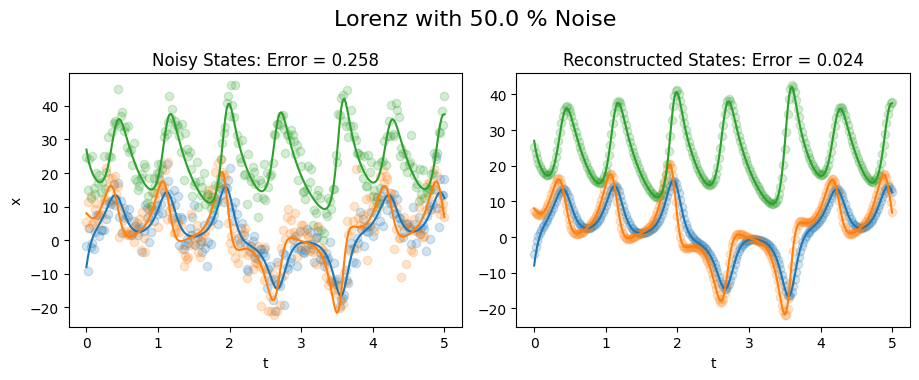

In [7]:
opt_states,opt_params = discoverLorenz.unravel_states_and_parameters(discoverLorenz.states_and_parameters)
state_mask = discoverLorenz.state_mask

##Overlay
RelError_data = np.linalg.norm((x_data - x_data_true)*state_mask)/np.linalg.norm(x_data_true*state_mask)
RelError_reconstuct = np.linalg.norm((opt_states - x_data_true)*state_mask)/np.linalg.norm(x_data_true*state_mask)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
axs[0].plot(T_grid,x_data_true,label = ['x_data','y_data','z_data'])
axs[0].scatter(T_grid,x_data[:,0],marker = 'o',alpha=.2)
axs[0].scatter(T_grid,x_data[:,1],marker = 'o',alpha=.2)
axs[0].scatter(T_grid,x_data[:,2],marker = 'o',alpha=.2)
axs[0].set_title(f'Noisy States: Error = {RelError_data:.3f}')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x')

axs[1].scatter(T_grid,opt_states[:,0],marker = 'o',alpha=.2)
axs[1].scatter(T_grid,opt_states[:,1],marker = 'o',alpha=.2)
axs[1].scatter(T_grid,opt_states[:,2],marker = 'o',alpha=.2)
axs[1].plot(T_grid,x_data_true,label = ['x_found','y_found','z_found'])
axs[1].set_title(f'Reconstructed States: Error = {RelError_reconstuct:.3f}')
axs[1].set_xlabel('t')


plt.suptitle(f'Lorenz with {percent_noise*100} % Noise', fontsize=16)
plt.tight_layout(rect=[0.02, 0.04, .95, 1]) 
fig.show()

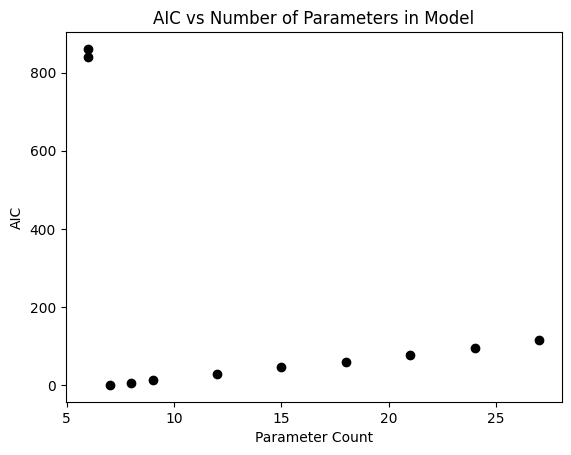

In [8]:
M,N = np.shape(FullModels)
Name = str(percent_noise) + "Noise" + str(FractionOfDataMissing) + "Missing"


for i in range(M):
    plt.scatter(np.count_nonzero(FullModels[i,2]),FullModels[i,0],c = 'black')

plt.title("AIC vs Number of Parameters in Model")
plt.xlabel("Parameter Count")
plt.ylabel("AIC")
plt.show()